# TPOSE24 drift from its TPOSE6 boundary conditions

The nested **TPOSE24** (1/24°) run takes its open-boundary conditions from
**TPOSE6** (1/6°) daily averages, so it is pinned to the parent at the domain
edges and free to evolve in the interior. This notebook quantifies how far the
interior walks away from the parent over Oct–Dec 2012.

All reductions are computed over the **TPOSE24 footprint** on each model's
native grid (`build_drift_cache.py`). For the 2-D maps, TPOSE24 is
conservatively coarse-grained onto the TPOSE6 grid so the mesoscale structure
the parent cannot resolve is not counted as drift.

Metrics: (1) volume-mean θ / S drift, (2) θ / S bias vs depth and time,
(3) steric-height drift split into thermosteric / halosteric, (4) surface
bias maps and RMSE, (5) drift vs distance from the open boundary.

In [1]:
import os, warnings
warnings.filterwarnings('ignore')
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import cmocean.cm as cmo
import drift_utils as d

plt.rcParams.update({'font.size': 11, 'axes.titlesize': 12, 'axes.labelsize': 11})
C = {'TP6': '#1f77b4', 'TP24': '#d62728'}
L = {'TP6': d.MODELS['TP6']['label'], 'TP24': d.MODELS['TP24']['label']}

ds6 = xr.open_dataset(d.cache_path('drift_cache_TP6.nc'))
ds24 = xr.open_dataset(d.cache_path('drift_cache_TP24.nc'))
# align on the common daily axis ONLY -- each run keeps its native depth grid
# (TP6 has 66 levels, TP24 has 138; a full align would intersect z to the few
# exactly-shared deep levels and empty out the upper-ocean plots)
common = np.intersect1d(ds6.time.values, ds24.time.values)
ds6 = ds6.sel(time=common)
ds24 = ds24.sel(time=common)
t = ds6.time.values
print('common days:', len(t), str(t[0])[:10], '->', str(t[-1])[:10])
print('footprint:', ds24.attrs['footprint'])

common days: 91 2012-10-01 -> 2012-12-30
footprint: (209.3541259765625, 230.6457977294922, -5.479166507720947, 10.479166984558105)


## 1. Heat & salt drift

Footprint volume-mean potential temperature and salinity for both runs, and the
TPOSE24 − TPOSE6 difference. A growing gap = the interior is not staying in
balance with the parent it is forced by. A straight line through the difference
gives the drift rate.

θ drift over run: -0.0008 °C | S drift: -0.0002 g/kg


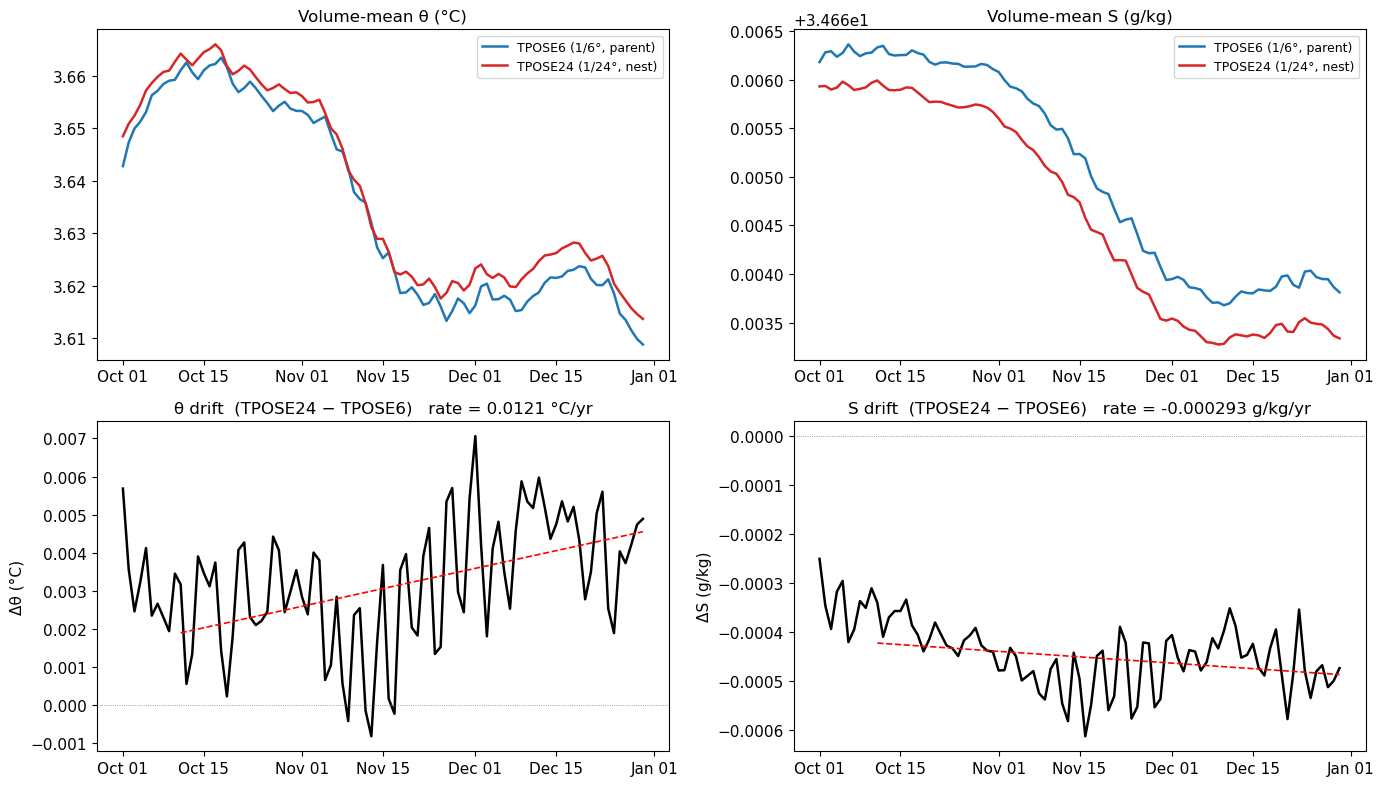

In [2]:
fig, ax = plt.subplots(2, 2, figsize=(14, 8))
for k, ds in [('TP6', ds6), ('TP24', ds24)]:
    ax[0,0].plot(t, ds.volmean_theta, color=C[k], lw=1.8, label=L[k])
    ax[0,1].plot(t, ds.volmean_salt, color=C[k], lw=1.8, label=L[k])
ax[0,0].set_title('Volume-mean θ (°C)'); ax[0,0].legend(fontsize=9)
ax[0,1].set_title('Volume-mean S (g/kg)'); ax[0,1].legend(fontsize=9)

dth = (ds24.volmean_theta - ds6.volmean_theta).values
dsa = (ds24.volmean_salt - ds6.volmean_salt).values
tnum = mdates.date2num(t)
for a, y, lab, u in [(ax[1,0], dth, 'θ', '°C'), (ax[1,1], dsa, 'S', 'g/kg')]:
    a.plot(t, y, color='k', lw=1.8)
    a.axhline(0, color='gray', lw=0.6, ls=':')
    # drift rate from a linear fit after a 10-day spin-up
    m = (t - t[0]) >= np.timedelta64(10, 'D')
    p = np.polyfit(tnum[m], y[m], 1)
    a.plot(t[m], np.polyval(p, tnum[m]), 'r--', lw=1.2)
    a.set_title(f'{lab} drift  (TPOSE24 − TPOSE6)   rate = {p[0]*365:.3g} {u}/yr')
    a.set_ylabel(f'Δ{lab} ({u})')
for a in ax.ravel(): a.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.tight_layout(); fig.savefig('fig1_heat_salt_drift.png', dpi=140)
print('θ drift over run: %.4f °C | S drift: %.4f g/kg' % (dth[-1]-dth[0], dsa[-1]-dsa[0]))

## 2. Where the drift lives (depth × time)

Horizontally-averaged θ and S difference (TPOSE24 − TPOSE6) as a function of
depth and time. TPOSE24 profiles are interpolated onto the TPOSE6 depth axis
before differencing. This shows whether drift is a surface-flux signal, a
thermocline signal, or reaches into the deep water column.

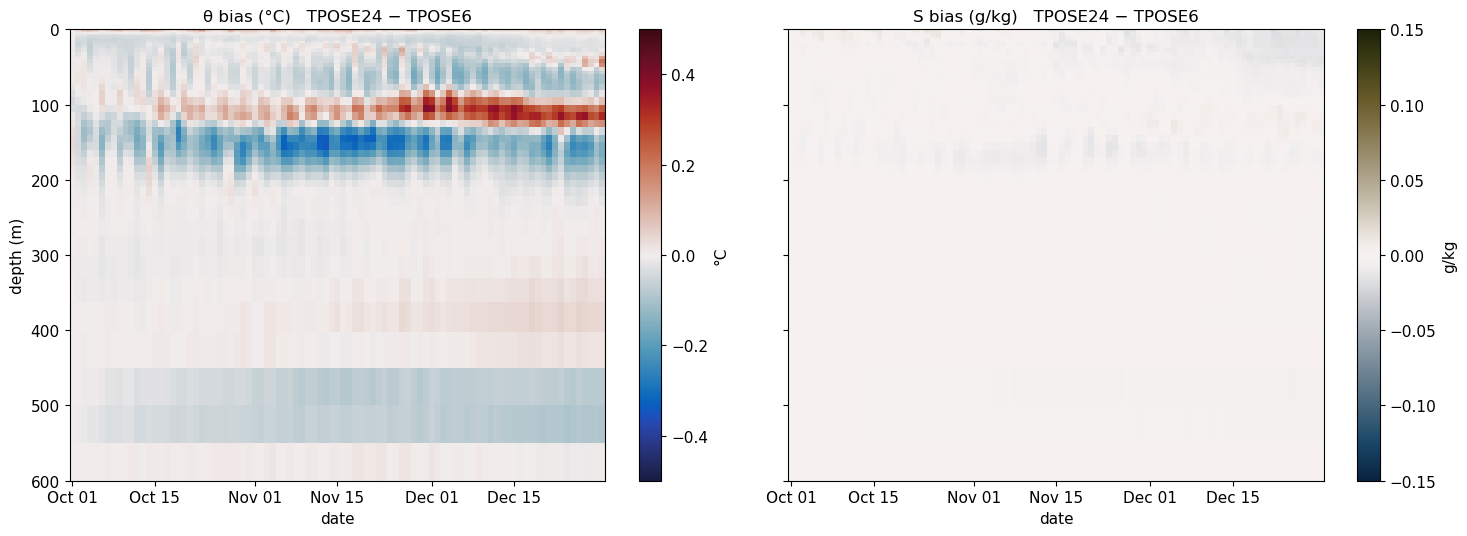

In [3]:
z6 = ds6.z.values                         # target (coarser) depth axis
def to_z6(ds):
    prof = ds.transpose('time', 'z').values
    out = np.empty((prof.shape[0], z6.size))
    for i in range(prof.shape[0]):
        out[i] = np.interp(-z6, -ds.z.values, prof[i])   # depth increasing
    return out
dTz = (to_z6(ds24.theta_prof) - to_z6(ds6.theta_prof)).T   # (z, time)
dSz = (to_z6(ds24.salt_prof) - to_z6(ds6.salt_prof)).T

fig, ax = plt.subplots(1, 2, figsize=(15, 5.5), sharey=True)
for a, fld, ttl, cm, lim, u in [
        (ax[0], dTz, 'θ bias (°C)', cmo.balance, 0.5, '°C'),
        (ax[1], dSz, 'S bias (g/kg)', cmo.diff, 0.15, 'g/kg')]:
    im = a.pcolormesh(t, -z6, fld, cmap=cm, vmin=-lim, vmax=lim, shading='auto')
    a.set_ylim(600, 0); a.set_title(f'{ttl}   TPOSE24 − TPOSE6')
    a.set_xlabel('date'); a.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    fig.colorbar(im, ax=a, label=u)
ax[0].set_ylabel('depth (m)')
fig.tight_layout(); fig.savefig('fig2_bias_hovmoller.png', dpi=140)

## 3. Steric-height drift (thermosteric vs halosteric)

Steric height of the footprint-mean column relative to each run's own day-0
profile, decomposed into a **thermosteric** part (θ varying, S fixed) and a
**halosteric** part (S varying, θ fixed). The gap between the TPOSE24 and
TPOSE6 curves is the steric drift of the nest relative to its parent; the
decomposition attributes it to heat vs salt. The mean model sea-surface height
(ETAN) difference is shown alongside as the drift the model actually carries.

steric drift end: total 0.08 cm | thermo 0.00 | halo 0.08


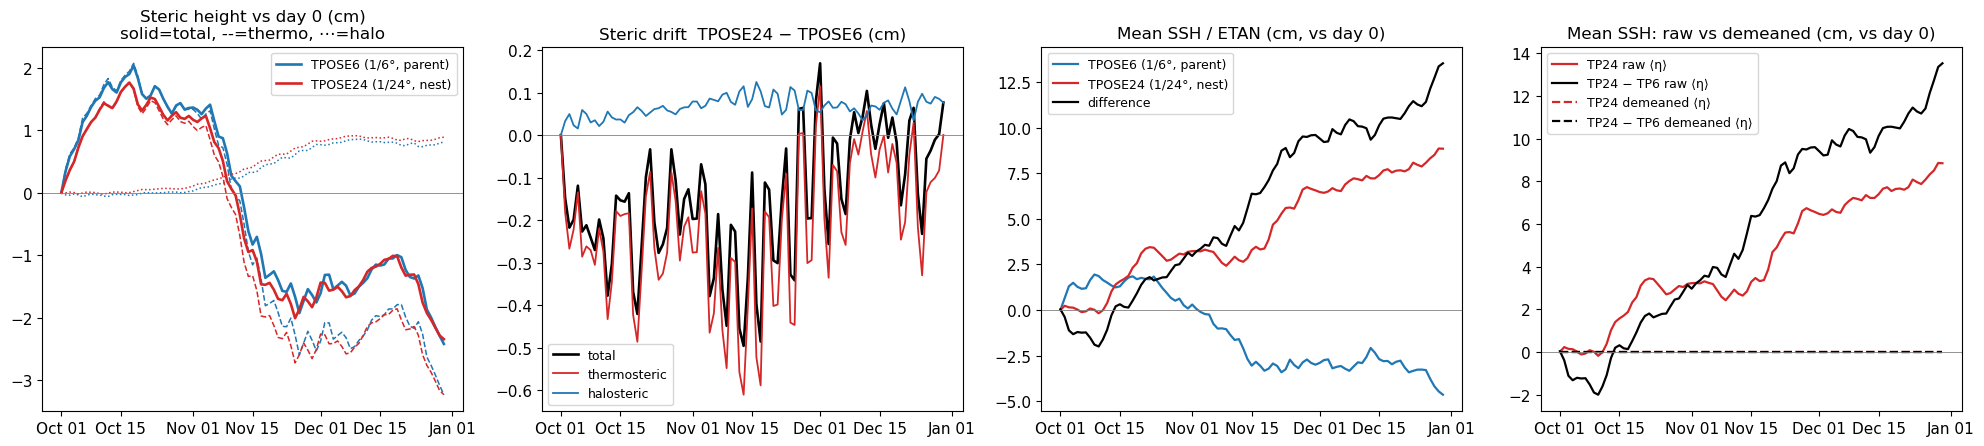

In [4]:
fig, ax = plt.subplots(1, 4, figsize=(20, 4.6))
for k, ds in [('TP6', ds6), ('TP24', ds24)]:
    ax[0].plot(t, 100*ds.steric_total, color=C[k], lw=1.9, label=L[k])
    ax[0].plot(t, 100*ds.steric_thermo, color=C[k], lw=1.1, ls='--')
    ax[0].plot(t, 100*ds.steric_halo, color=C[k], lw=1.1, ls=':')
ax[0].set_title('Steric height vs day 0 (cm)\nsolid=total, --=thermo, ⋯=halo')
ax[0].legend(fontsize=9); ax[0].axhline(0, color='gray', lw=0.6)

gap_t = 100*(ds24.steric_total - ds6.steric_total).values
gap_th = 100*(ds24.steric_thermo - ds6.steric_thermo).values
gap_h = 100*(ds24.steric_halo - ds6.steric_halo).values
ax[1].plot(t, gap_t, 'k', lw=1.9, label='total')
ax[1].plot(t, gap_th, color='#d62728', lw=1.3, label='thermosteric')
ax[1].plot(t, gap_h, color='#1f77b4', lw=1.3, label='halosteric')
ax[1].axhline(0, color='gray', lw=0.6); ax[1].legend(fontsize=9)
ax[1].set_title('Steric drift  TPOSE24 − TPOSE6 (cm)')

deta = 100*(ds24.etan_mean - ds6.etan_mean).values
ax[2].plot(t, 100*(ds6.etan_mean-ds6.etan_mean.values[0]), color=C['TP6'], lw=1.6, label=L['TP6'])
ax[2].plot(t, 100*(ds24.etan_mean-ds24.etan_mean.values[0]), color=C['TP24'], lw=1.6, label=L['TP24'])
ax[2].plot(t, deta, 'k', lw=1.6, label='difference')
ax[2].axhline(0, color='gray', lw=0.6); ax[2].legend(fontsize=9)
ax[2].set_title('Mean SSH / ETAN (cm, vs day 0)')

# demeaned SSH: subtract the instantaneous domain-mean from each field, then
# re-take the domain mean (identically ~0) for each run and their difference
def dm_mean(ds):
    em = ds.etan_map.values.reshape(len(t), -1)
    dm = em - np.nanmean(em, axis=1)[:, None]
    return np.nanmean(dm, axis=1)
dm6, dm24 = dm_mean(ds6), dm_mean(ds24)
ax[3].plot(t, 100*(ds24.etan_mean-ds24.etan_mean.values[0]).values, color=C['TP24'], lw=1.6, label='TP24 raw ⟨η⟩')
ax[3].plot(t, deta, 'k', lw=1.6, label='TP24 − TP6 raw ⟨η⟩')
ax[3].plot(t, 100*(dm24-dm24[0]), color=C['TP24'], lw=1.6, ls='--', label='TP24 demeaned ⟨η⟩')
ax[3].plot(t, 100*(dm24-dm6), 'k--', lw=1.6, label='TP24 − TP6 demeaned ⟨η⟩')
ax[3].axhline(0, color='gray', lw=0.6); ax[3].legend(fontsize=9)
ax[3].set_title('Mean SSH: raw vs demeaned (cm, vs day 0)')

for a in ax: a.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.tight_layout(); fig.savefig('fig3_steric.png', dpi=140)
print('steric drift end: total %.2f cm | thermo %.2f | halo %.2f' % (gap_t[-1], gap_th[-1], gap_h[-1]))

## 4. Surface bias maps and RMSE

Upper-100 m θ and S difference (TPOSE24 − TPOSE6) averaged over the last 10
days of the run, on the shared TPOSE6 grid. The area-weighted RMSE and bias
time series show whether the mismatch is growing.

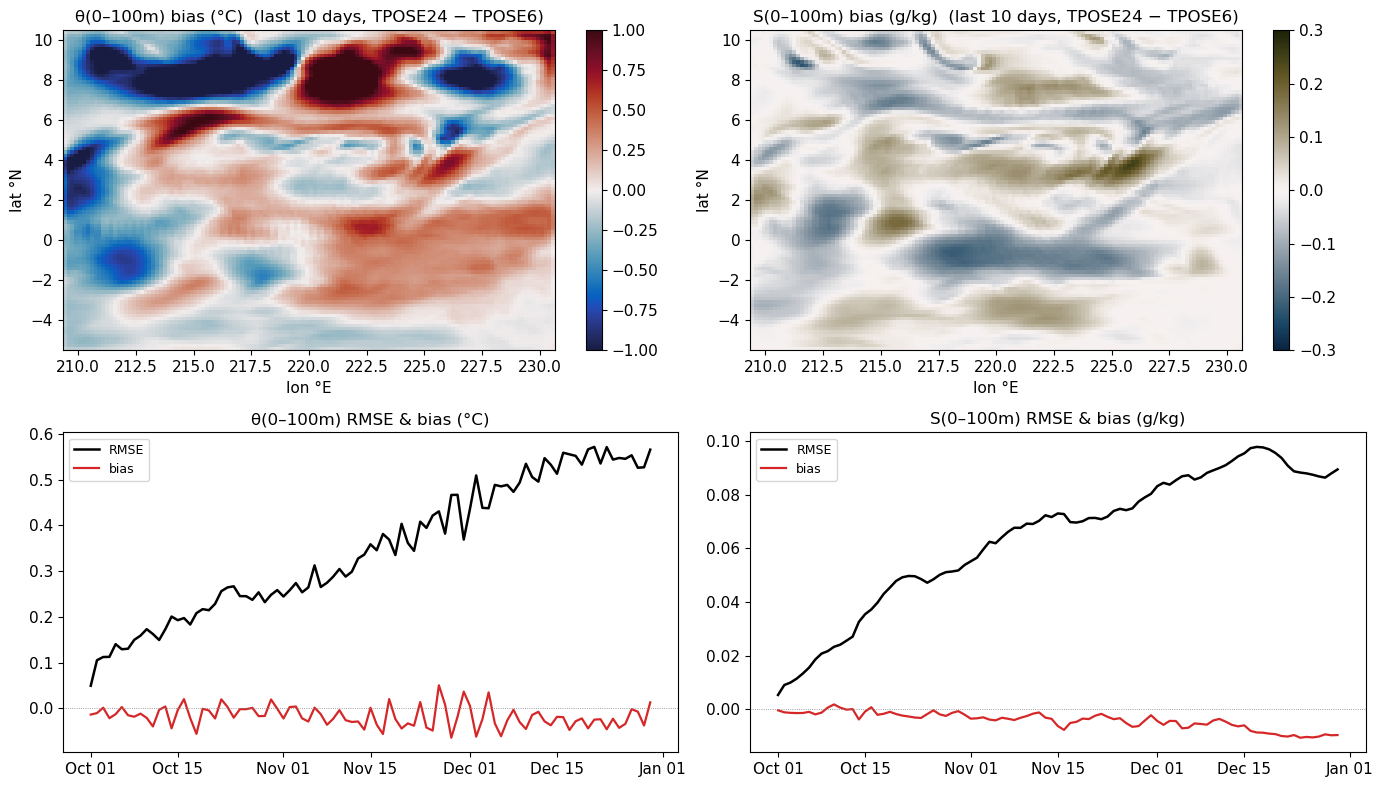

In [5]:
def wmean(field2d, lat):
    w = np.cos(np.deg2rad(lat))[:, None] * np.ones((1, field2d.shape[1]))
    v = np.isfinite(field2d)
    return np.nansum(np.where(v, field2d*w, 0))/np.nansum(np.where(v, w, 0))
def wrmse(diff, lat):
    return np.sqrt(wmean(diff**2, lat))

lat = ds6.y.values; lon = ds6.x.values
dT = ds24.t100 - ds6.t100      # (time, y, x)
dS = ds24.s100 - ds6.s100
last = (t - t[-1]) >= -np.timedelta64(10, 'D')

fig, ax = plt.subplots(2, 2, figsize=(14, 8))
for a, fld, ttl, cm, lim in [
        (ax[0,0], dT.isel(time=last).mean('time'), 'θ(0–100m) bias (°C)', cmo.balance, 1.0),
        (ax[0,1], dS.isel(time=last).mean('time'), 'S(0–100m) bias (g/kg)', cmo.diff, 0.3)]:
    im = a.pcolormesh(lon, lat, fld, cmap=cm, vmin=-lim, vmax=lim, shading='auto')
    a.set_title(f'{ttl}  (last 10 days, TPOSE24 − TPOSE6)')
    a.set_xlabel('lon °E'); a.set_ylabel('lat °N'); fig.colorbar(im, ax=a)

for a, dd, lab, u in [(ax[1,0], dT, 'θ(0–100m)', '°C'), (ax[1,1], dS, 'S(0–100m)', 'g/kg')]:
    rmse = np.array([wrmse(dd.isel(time=i).values, lat) for i in range(len(t))])
    bias = np.array([wmean(dd.isel(time=i).values, lat) for i in range(len(t))])
    a.plot(t, rmse, 'k', lw=1.8, label='RMSE')
    a.plot(t, bias, color='#d62728', lw=1.6, label='bias')
    a.axhline(0, color='gray', lw=0.6, ls=':'); a.legend(fontsize=9)
    a.set_title(f'{lab} RMSE & bias ({u})')
    a.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
fig.tight_layout(); fig.savefig('fig4_spatial_bias.png', dpi=140)

## 5. Drift vs distance from the boundary

The OBCS sponge (`spongeThickness=8` ≈ 37 km) relaxes **velocity only**; T/S are
prescribed only at the boundary row, not sponged. So the upper-100 m θ
difference vs distance from the edge is the tracer boundary-consistency check.

Bins are refined near the boundary to resolve the sponge zone. The total RMS is
split into a **systematic** part (RMS of the time-mean difference — genuine mean
drift) and a **fluctuating** part (RMS about the time mean — the free mesoscale
eddy field TP24 makes that TP6 lacks), since only the systematic part signals
the interior becoming inconsistent with the prescribed boundary. The
near-boundary vs interior time series shows whether the edge is staying pinned
or creeping over the run.

sponge-zone Δθ: RMS 0.162->0.419 °C, bias -0.078->-0.040 °C (start->end)


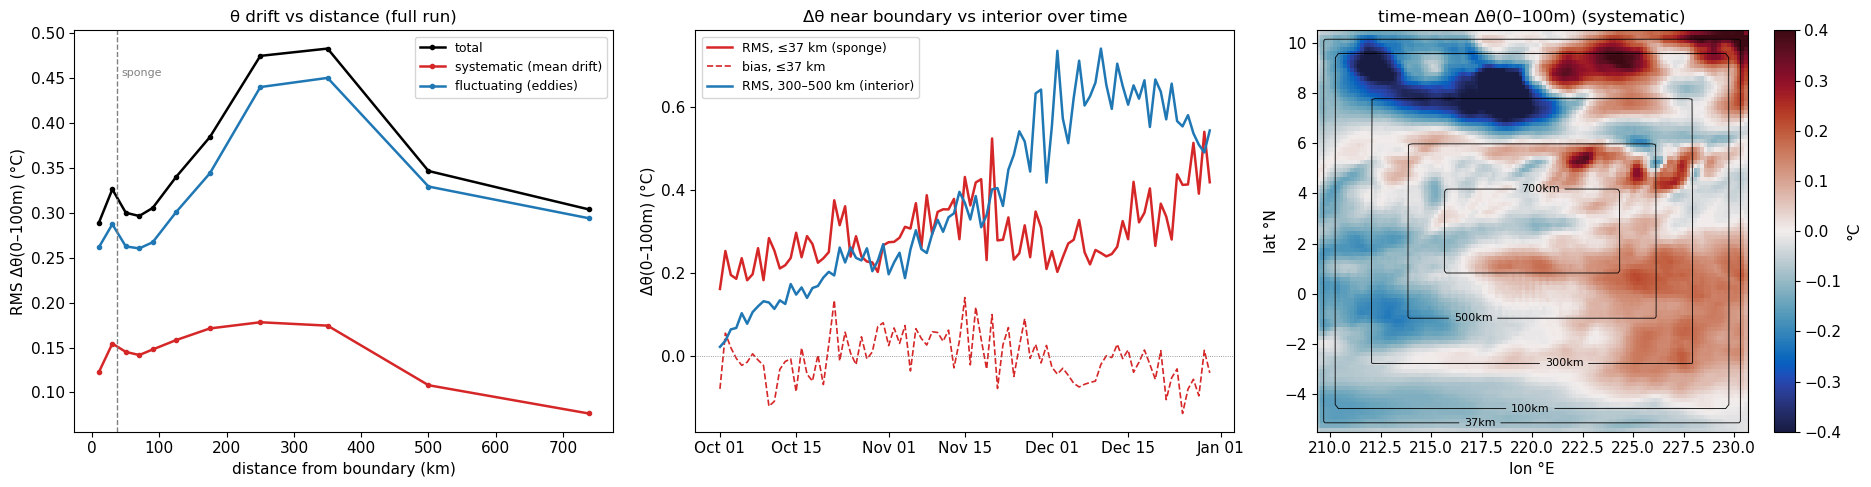

In [6]:
dist = ds6.dist_km.values
dTv = dT.values                                   # (time, y, x)
SPONGE_KM = 37.0                                  # spongeThickness=8 @ 1/24 deg

mean_field = np.nanmean(dTv, axis=0)              # systematic (time-mean) drift
anom = dTv - mean_field[None]                     # fluctuating (eddy) part

edges = np.array([0,20,40,60,80,100,150,200,300,400,600,900], float)
edges = np.r_[edges[edges < np.nanmax(dist)], np.nanmax(dist)]
ctr = 0.5*(edges[:-1]+edges[1:])
def binrms(a2d_or_3d):
    out = []
    for e0, e1 in zip(edges[:-1], edges[1:]):
        mb = (dist >= e0) & (dist < e1)
        v = a2d_or_3d[..., mb]
        out.append(np.sqrt(np.nanmean(v**2)) if np.isfinite(v).any() else np.nan)
    return np.array(out)

fig, ax = plt.subplots(1, 3, figsize=(19, 5))
ax[0].plot(ctr, binrms(dTv),        'k-o', ms=3, lw=1.8, label='total')
ax[0].plot(ctr, binrms(mean_field), color='#d62728', marker='o', ms=3, lw=1.8, label='systematic (mean drift)')
ax[0].plot(ctr, binrms(anom),       color='#1f77b4', marker='o', ms=3, lw=1.8, label='fluctuating (eddies)')
ax[0].axvline(SPONGE_KM, color='gray', ls='--', lw=1); ax[0].text(SPONGE_KM+6, ax[0].get_ylim()[1]*0.9, 'sponge', fontsize=8, color='gray')
ax[0].set_xlabel('distance from boundary (km)'); ax[0].set_ylabel('RMS Δθ(0–100m) (°C)')
ax[0].set_title('θ drift vs distance (full run)'); ax[0].legend(fontsize=9)

# near-boundary (within sponge) vs interior band, over time
mb_edge = dist <= SPONGE_KM
mb_int = (dist >= 300) & (dist <= 500)
rms_edge = np.array([np.sqrt(np.nanmean(dTv[i][mb_edge]**2)) for i in range(len(t))])
bias_edge = np.array([np.nanmean(dTv[i][mb_edge]) for i in range(len(t))])
rms_int = np.array([np.sqrt(np.nanmean(dTv[i][mb_int]**2)) for i in range(len(t))])
ax[1].plot(t, rms_edge, color='#d62728', lw=1.8, label=f'RMS, ≤{SPONGE_KM:.0f} km (sponge)')
ax[1].plot(t, bias_edge, color='#d62728', lw=1.2, ls='--', label=f'bias, ≤{SPONGE_KM:.0f} km')
ax[1].plot(t, rms_int, color='#1f77b4', lw=1.8, label='RMS, 300–500 km (interior)')
ax[1].axhline(0, color='gray', lw=0.6, ls=':'); ax[1].legend(fontsize=9)
ax[1].set_title('Δθ near boundary vs interior over time')
ax[1].set_ylabel('Δθ(0–100m) (°C)'); ax[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))

im = ax[2].pcolormesh(ds6.x.values, ds6.y.values, mean_field,
                      cmap=cmo.balance, vmin=-0.4, vmax=0.4, shading='auto')
cs = ax[2].contour(ds6.x.values, ds6.y.values, dist, levels=[SPONGE_KM,100,300,500,700],
                   colors='k', linewidths=0.6)
ax[2].clabel(cs, fmt='%dkm', fontsize=8)
ax[2].set_title('time-mean Δθ(0–100m) (systematic)')
ax[2].set_xlabel('lon °E'); ax[2].set_ylabel('lat °N'); fig.colorbar(im, ax=ax[2], label='°C')
fig.tight_layout(); fig.savefig('fig5_distance_boundary.png', dpi=140)
print('sponge-zone Δθ: RMS %.3f->%.3f °C, bias %.3f->%.3f °C (start->end)'
      % (rms_edge[0], rms_edge[-1], bias_edge[0], bias_edge[-1]))

## Summary

In [7]:
print('=== TPOSE24 drift from TPOSE6 boundary conditions, %s .. %s ===' % (str(t[0])[:10], str(t[-1])[:10]))
print('volume-mean θ drift : %+.4f °C  (%+.4f °C/yr)' % (dth[-1]-dth[0], np.polyfit(tnum[(t-t[0])>=np.timedelta64(10,'D')], dth[(t-t[0])>=np.timedelta64(10,'D')],1)[0]*365))
print('volume-mean S drift : %+.4f g/kg' % (dsa[-1]-dsa[0]))
print('steric drift (total): %+.2f cm  = thermo %+.2f + halo %+.2f' % (gap_t[-1], gap_th[-1], gap_h[-1]))
print('mean SSH drift      : %+.2f cm' % deta[-1])
print('figures: fig1..fig5 written to drift_test/')

=== TPOSE24 drift from TPOSE6 boundary conditions, 2012-10-01 .. 2012-12-30 ===
volume-mean θ drift : -0.0008 °C  (+0.0121 °C/yr)
volume-mean S drift : -0.0002 g/kg
steric drift (total): +0.08 cm  = thermo +0.00 + halo +0.08
mean SSH drift      : +13.53 cm
figures: fig1..fig5 written to drift_test/
